<a href="https://colab.research.google.com/github/AleksandrMac/learning/blob/main/ai/practic/2/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №2. Ассистент сметчика
## 📖 Описание проекта
RAG-система для работы с нормативной базой сметного дела, реализованная на примере **«Методики 421»** (приказ Минстроя РФ) и одного из официальных дополнений к ней. Проект решает ключевую проблему нормативного поиска: корректный учёт версионности и предоставление контекста строго на заданную дату. Архитектура спроектирована с учётом дальнейшего масштабирования на смежные строительные домены (проектирование, управление, эксплуатация).

### 🔬 Сравнительный эксперимент (этап подготовки данных)
На этапе индексации проводится сравнение двух подходов к построению графа знаний и векторизации:
| Подход | Реализация | Оцениваемые метрики |
|--------|------------|---------------------|
| **🔹 Custom Graph (`networkx`)** | Ручная экстракция сущностей, явное хранение связей `документ → пункт → изменение`, темпоральные фильтры на уровне приложения | • Точность временных срезов (`Accuracy@Date`)<br>• Время индексации<br>• Latency retrieval<br>• Контроль галлюцинаций |
| **🔹 LightRAG** | Автоматическая экстракция связей через LLM, встроенный dual-level retrieval, инкрементальное обновление | • Полнота захвата зависимостей<br>• Скорость индексации/поиска<br>• Стабильность на шумных данных<br>• Качество обогащения контекста |

Результаты эксперимента фиксируются в виде бенчмарк-отчёта и включают сравнительные таблицы, графики latency и примеры ошибок каждого подхода.

### 🤖 Генерация ответов
- **Основная модель:** `Qwen2.5` (Instruct) — высокая точность на технической документации, нативная поддержка русского языка.
- **Бэзлайн для сравнения:** русскоязычная модель (например, `Saiga-Llama3-8B` или `ruGPT-3.5`) для оценки влияния архитектуры retrieval на итоговое качество генерации.
- Все ответы сопровождаются трассировкой источников с указанием номера пункта, документа-основания и даты актуальности.

### 🛠️ Технологический стек
`Python` • `LangChain` • `ChromaDB` • `NetworkX` • `LightRAG` • `SentenceTransformers` • `Qwen2.5` • `Google Colab`

## Подготовка данных


### Загрузка данных

Функция `load_source_data()` обеспечивает:
- ✅ Проверку наличия файла перед скачиванием (`skip_existing`)
- ✅ Приоритет: прямой `url` → конструирование из `MAIN_URL_MASK + publication_number`
- ✅ Повторные попытки при сбоях сети (`MAX_RETRIES`)
- ✅ Опциональную верификацию по MD5-хэшу
- ✅ Структурированный результат для интеграции с пайплайном

Для Colab: базовая директория `/content`, для локальной разработки — укажите `base_dir="./data"`.

In [5]:
# 📦 Ячейка: Загрузчик нормативных документов с проверкой и fallback
import os
import time
import hashlib
import requests
from pathlib import Path
from typing import List, Dict, Optional
from urllib.parse import urlparse

# ⚙️ Настройки
MAIN_URL_MASK = "http://publication.pravo.gov.ru/file/pdf?eoNumber={}"
DOWNLOAD_TIMEOUT = 60  # секунд
MAX_RETRIES = 3
RETRY_DELAY = 2  # секунд

def _calculate_file_hash(filepath: str, algorithm: str = "md5") -> Optional[str]:
    """Вычисляет хэш файла для проверки целостности."""
    if not os.path.exists(filepath):
        return None
    hash_func = hashlib.new(algorithm)
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(8192), b""):
            hash_func.update(chunk)
    return hash_func.hexdigest()

def _resolve_url(item: Dict) -> Optional[str]:
    """Определяет URL для скачивания: прямой URL → маска + publication_number."""
    # Приоритет 1: прямой URL (если есть и не пустой после trim)
    if url := item.get("url", "").strip():
        return url
    
    # Приоритет 2: сконструировать из маски + publication_number
    if pub_num := item.get("publication_number", "").strip():
        if MAIN_URL_MASK:
            return MAIN_URL_MASK.format(pub_num)
    
    return None

def _ensure_directory(filepath: str) -> bool:
    """Создаёт директорию для файла, если не существует."""
    try:
        Path(filepath).parent.mkdir(parents=True, exist_ok=True)
        return True
    except Exception as e:
        print(f"❌ Ошибка создания директории для {filepath}: {e}")
        return False

def download_file(url: str, filepath: str, timeout: int = DOWNLOAD_TIMEOUT) -> bool:
    """Скачивает файл с прогресс-баром и обработкой ошибок."""
    try:
        response = requests.get(url, stream=True, timeout=timeout)
        response.raise_for_status()
        
        total_size = int(response.headers.get('content-length', 0))
        downloaded = 0
        
        with open(filepath, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)
                    # Прогресс для Colab
                    if total_size > 0:
                        percent = min(100, int(100 * downloaded / total_size))
                        print(f"\r⬇️  {Path(filepath).name}: {percent}% ", end="")
        
        print(f"\r✅ {Path(filepath).name}: загрузка завершена")
        return True
        
    except requests.exceptions.RequestException as e:
        print(f"\n❌ Ошибка загрузки {url}: {e}")
        return False
    except IOError as e:
        print(f"\n❌ Ошибка записи файла {filepath}: {e}")
        return False

def load_source_data(
    input_data: List[Dict], 
    base_dir: str = "/content",
    skip_existing: bool = True,
    verify_hash: bool = False,
    expected_hashes: Optional[Dict[str, str]] = None
) -> List[Dict]:
    """
    Загружает нормативные документы с проверкой наличия и целостности.
    
    Args:
        input_data: Список словарей с метаданными документов
        base_dir: Базовая директория для сохранения (по умолчанию /content для Colab)
        skip_existing: Пропускать уже скачанные файлы (проверка по размеру > 0)
        verify_hash: Проверять целостность по MD5-хэшу
        expected_hashes: Словарь {filepath: expected_hash} для верификации
    
    Returns:
        Список результатов загрузки с метаданными и статусом
    """
    results = []
    
    for idx, item in enumerate(input_data, 1):
        print(f"\n[{idx}/{len(input_data)}] Обработка: {item.get('name', 'Без названия')[:60]}...")
        
        # Резолвим путь к файлу
        rel_path = item.get("file", "").strip()
        if not rel_path:
            print("⚠️  Пропуск: не указан путь к файлу (field 'file')")
            results.append({**item, "status": "skipped", "reason": "no_file_path"})
            continue
            
        filepath = os.path.join(base_dir, rel_path) if not rel_path.startswith("/") else rel_path
        
        # Проверка: файл уже существует
        if skip_existing and os.path.exists(filepath) and os.path.getsize(filepath) > 0:
            # Опциональная проверка хэша
            if verify_hash and expected_hashes:
                current_hash = _calculate_file_hash(filepath)
                expected = expected_hashes.get(filepath)
                if current_hash != expected:
                    print(f"⚠️  Хэш не совпадает. Перезагрузка...")
                else:
                    print(f"✅ Файл уже загружен и верифицирован: {filepath}")
                    results.append({**item, "status": "cached", "filepath": filepath})
                    continue
            else:
                print(f"✅ Файл уже загружен: {filepath}")
                results.append({**item, "status": "cached", "filepath": filepath})
                continue
        
        # Создаём директорию
        if not _ensure_directory(filepath):
            results.append({**item, "status": "failed", "reason": "mkdir_failed"})
            continue
            
        # Определяем URL
        url = _resolve_url(item)
        if not url:
            print("⚠️  Пропуск: не удалось определить URL для скачивания")
            results.append({**item, "status": "skipped", "reason": "no_url"})
            continue
            
        print(f"🔗 URL: {url}")
        
        # Скачивание с повторами
        success = False
        for attempt in range(MAX_RETRIES):
            if download_file(url, filepath):
                success = True
                break
            print(f"🔄 Попытка {attempt + 2}/{MAX_RETRIES} через {RETRY_DELAY}с...")
            time.sleep(RETRY_DELAY)
            
        if not success:
            results.append({**item, "status": "failed", "reason": "download_failed", "url": url})
            continue
            
        # Финальная верификация (если запрошена)
        if verify_hash and expected_hashes:
            current_hash = _calculate_file_hash(filepath)
            expected = expected_hashes.get(filepath)
            if current_hash != expected:
                print(f"❌ Хэш не совпадает! Ожид: {expected}, Получено: {current_hash}")
                results.append({**item, "status": "failed", "reason": "hash_mismatch"})
                continue
                
        results.append({
            **item,
            "status": "downloaded",
            "filepath": filepath,
            "size_bytes": os.path.getsize(filepath)
        })
        
    # 📊 Итоговая статистика
    stats = {
        "total": len(input_data),
        "downloaded": sum(1 for r in results if r["status"] == "downloaded"),
        "cached": sum(1 for r in results if r["status"] == "cached"),
        "failed": sum(1 for r in results if r["status"] == "failed"),
        "skipped": sum(1 for r in results if r["status"] == "skipped")
    }
    
    print(f"\n📈 Статистика загрузки: {stats}")
    return results

/home/aleksandr/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


In [6]:
main_url_mask="http://publication.pravo.gov.ru/file/pdf?eoNumber=%1"
# reserve_url_mask="https://github.com/AleksandrMac/learning/tree/main/ai/practic/2/data/pdf/%1"
# Структура исходных данных
input_data = [
    {
        "original_text":"",
        "file":"data/pdf/20200804_421.pdf",
        "name":"Методика определения сметной стоимости строительства, реконструкции, капитального ремонта, сноса объектов капитального строительства, работ по сохранению объектов культурного наследия (памятников истории и культуры) народов Российской Федерации на территории Российской Федерации",
        "valid_from": "04.08.2020",
        "valid_to": None,
        "publication_date":   "24.09.2020",
        "publication_number": "0001202009240006",
        "registration_date":  "23.09.2020",
        "registration_number": 59986,
        "type": "base"
    }
]
# 🔐 Опционально: хэши для верификации (если есть эталон)
expected_hashes = {
    "/content/data/pdf/20200804_421.pdf": "abc123def456..."
}

# 🚀 Запуск загрузчика
results = load_source_data(
    input_data=input_data,
    base_dir=".",
    skip_existing=True,      # не качать повторно
    verify_hash=False,       # включить, если есть expected_hashes
    expected_hashes=expected_hashes
)

# 📥 Результат для следующего шага пайплайна
ready_docs = [r for r in results if r["status"] in ("downloaded", "cached")]
print(f"\n✅ Готово к парсингу: {len(ready_docs)} документов")


[1/1] Обработка: Методика определения сметной стоимости строительства, реконс...
✅ Файл уже загружен: ./data/pdf/20200804_421.pdf

📈 Статистика загрузки: {'total': 1, 'downloaded': 0, 'cached': 1, 'failed': 0, 'skipped': 0}

✅ Готово к парсингу: 1 документов


### 🖼️ Обработка сканированных документов
Система использует **гибридный парсер**: 
1. Нативное извлечение текста (`pdfplumber`) для векторных PDF
2. Постраничный OCR-fallback (`Tesseract + pdf2image`) при обнаружении сканов
3. Порог срабатывания: `<30 символов на страницу` → триггерит распознавание

Для табличных частей ГЭСН/ФЕР рекомендуется модуль `camelot-py` (в roadmap).

In [7]:
%pip install -q pdfplumber chardet

# import json
import chardet
from pathlib import Path
# from typing import List, Dict, Optional

Note: you may need to restart the kernel to use updated packages.


In [8]:
# # 📦 Установка системных и Python-зависимостей
# !apt-get install -y tesseract-ocr tesseract-ocr-rus tesseract-ocr-eng poppler-utils > /dev/null
# !pip install -q pdfplumber pytesseract pdf2image > /dev/null

import pdfplumber
import pytesseract
from pdf2image import convert_from_path
import re, os
from pathlib import Path

def extract_text_smart(pdf_path: str, min_char_threshold: int = 30) -> str:
    """
    1. Пробует извлечь текст через pdfplumber (быстро, точно)
    2. Если символов < threshold → конвертирует страницы в изображения и запускает Tesseract OCR
    3. Возвращает объединённый текст
    """
    print(f"🔍 Анализ {Path(pdf_path).name}...")
    full_text = []
    ocr_triggered = False
    
    with pdfplumber.open(pdf_path) as pdf:
        for i, page in enumerate(pdf.pages):
            txt = page.extract_text() or ""
            # Если на странице мало символов → вероятна картинка/скан
            if len(txt.strip()) < min_char_threshold:
                if not ocr_triggered:
                    print(f"   ⚠️ Страница {i+1}: текст не найден. Запускаю OCR...")
                    ocr_triggered = True
                    
                # Конвертируем только текущую страницу в изображение
                img = convert_from_path(pdf_path, first_page=i+1, last_page=i+1, dpi=200)[0]
                txt = pytesseract.image_to_string(img, lang='rus+eng+math')
                
            full_text.append(txt.strip())
            
    result = "\n".join(full_text)
    
    if ocr_triggered:
        print(f"✅ OCR завершён. Итого символов: {len(result)}")
    else:
        print(f"✅ Текст извлечён нативно. Символов: {len(result)}")
        
    return result

In [9]:
# 📄 Ячейка 2: Ядро парсера (улучшенная версия)
import re
from typing import List, Dict, Optional
from pathlib import Path

def clean_pdf_text(text: str) -> str:
    """
    Удаляет колонтитулы, номера страниц и артефакты печати.
    Оптимизировано под российские нормативные документы.
    """
    # Удаляем типичные колонтитулы (стр. 5, Лист 12, даты, номера приказов)
    footer_patterns = [
        r'^.*?\bстр\.?\s*\d+\b.*?$',           # "стр. 5", "стр 12"
        r'^.*?\bлист\.?\s*\d+\b.*?$',          # "Лист 12"
        r'^.*?\b\d{2}\.\d{2}\.\d{4}\b.*?$',    # даты в колонтитулах
        r'^.*?\b№\s*[\d/–-]+\b.*?$',           # номера документов
    ]
    
    for pattern in footer_patterns:
        text = re.sub(pattern, '', text, flags=re.MULTILINE | re.IGNORECASE)
    
    # Схлопываем множественные переносы и лишние пробелы
    text = re.sub(r'\n\s*\n', '\n', text)           # пустые строки
    text = re.sub(r'[ \t]+', ' ', text)             # лишние пробелы
    text = re.sub(r'\n\s+', '\n', text)             # пробелы после переноса
    
    return text.strip()


def extract_clauses(text: str, min_clause_len: int = 10) -> List[Dict[str, str]]:
    """
    Парсит текст в пункты с гибкой поддержкой российской нумерации.
    
    Поддерживаемые форматы:
    - Римские: II, III.1, IV.2.3
    - Арабские: 1, 1.1, 2.3.4, 1), 2)
    - Буквенные: а), б), в), г)
    - Вложенные: 1.1.1, а.1, (а)
    """
    # Расширенный паттерн с именованными группами
    clause_re = re.compile(
        r'''^
        \s*
        (?P<id>
            # Римские цифры: II, III.1, IV.2.3
            (?:[IVXLCDM]+(?:\.[\d.]+)?)|
            # Арабские: 1, 1.1, 2.3.4, 1), 1.
            (?:\d+(?:\.\d+)*[\.\)]?)|
            # Буквенные: а), б), (а), а.
            (?:\([а-яё]\)|[а-яё][\.\)]?)
        )
        \s+
        (?P<rest>.*)
        ''',
        re.MULTILINE | re.VERBOSE | re.IGNORECASE
    )
    
    clauses = []
    current_id = None
    current_text = []
    
    for match in clause_re.finditer(text):
        # Сохраняем предыдущий пункт
        if current_id:
            full_text = " ".join(current_text).strip()
            if len(full_text) >= min_clause_len:
                clauses.append({"id": current_id, "text": full_text})
        
        current_id = match.group("id").strip()
        current_text = [match.group("rest").strip()]
    
    # Не забываем последний пункт
    if current_id:
        full_text = " ".join(current_text).strip()
        if len(full_text) >= min_clause_len:
            clauses.append({"id": current_id, "text": full_text})
    
    return clauses


def parse_amendment_text(text: str) -> List[Dict[str, str]]:
    """
    Извлекает изменения из текста дополнений.
    
    Поддерживаемые форматы:
    - "Пункт X изложить в следующей редакции: ..."
    - "Дополнить пунктом X следующего содержания: ..."
    - "Пункт X признать утратившим силу"
    - "В пункте X слова '...' заменить на '...'"
    """
    changes = []
    
    # Паттерны для разных типов изменений
    patterns = [
        # "изложить в следующей редакции"
        (
            r'пункт\s+([^\s:;,]+)\s+изложить\s+в\s+следующей\s+редакции[:\s]*([\s\S]*?)(?=(?:пункт\s+|$|\Z|дополнить|признать))',
            lambda m: {"target_clause": m.group(1).strip(), "new_text": m.group(2).strip(), "change_type": "replace"}
        ),
        # "дополнить пунктом"
        (
            r'дополнить\s+пунктом\s+([^\s:;,]+)\s+следующего\s+содержания[:\s]*([\s\S]*?)(?=(?:пункт\s+|$|\Z|изложить|признать))',
            lambda m: {"target_clause": m.group(1).strip(), "new_text": m.group(2).strip(), "change_type": "add"}
        ),
        # "признать утратившим силу"
        (
            r'пункт\s+([^\s:;,]+)\s+признать\s+утратившим\s+силу',
            lambda m: {"target_clause": m.group(1).strip(), "new_text": "", "change_type": "delete"}
        ),
        # "заменить слова"
        (
            r'в\s+пункте\s+([^\s:;,]+)\s+слова\s+[\'"]([^\'"]+)[\'"]\s+заменить\s+на\s+[\'"]([^\'"]+)[\'"]',
            lambda m: {
                "target_clause": m.group(1).strip(), 
                "old_text": m.group(2).strip(),
                "new_text": m.group(3).strip(),
                "change_type": "modify"
            }
        ),
    ]
    
    for pattern, extractor in patterns:
        for match in re.finditer(pattern, text, re.IGNORECASE):
            change = extractor(match)
            if change.get("target_clause") and change.get("new_text") is not None:
                changes.append(change)
    
    return changes


def generate_doc_id(title: str, publication_number: Optional[str] = None) -> str:
    """
    Генерирует стабильный ID документа.
    Приоритет: publication_number → заголовок → имя файла.
    """
    if publication_number:
        return f"PN_{publication_number}"
    
    # Очищаем заголовок от спецсимволов
    clean_title = re.sub(r'[^a-zA-Zа-яА-Я0-9_\s]', '', title)
    # Берём первые значимые слова
    words = [w for w in clean_title.split() if len(w) > 3][:3]
    return "_".join(words).upper()[:50] if words else "UNKNOWN_DOC"


def process_normative_pdf(
    pdf_path: str, 
    doc_type: str = "base", 
    valid_from: Optional[str] = None,
    publication_number: Optional[str] = None,
    min_clause_len: int = 10
) -> Dict:
    """
    Основная функция парсинга нормативных документов.
    
    Args:
        pdf_path: Путь к PDF-файлу
        doc_type: 'base' или 'amendment'
        valid_from: Дата вступления в силу (ISO format)
        publication_number: Номер публикации для стабильного ID
        min_clause_len: Минимальная длина пункта для фильтрации шума
    
    Returns:
        Словарь с метаданными и извлечённой структурой
    """
    # Извлекаем текст с умным fallback на OCR
    full_text = extract_text_smart(pdf_path)
    full_text = clean_pdf_text(full_text)
    
    if not full_text or len(full_text) < 50:
        raise ValueError(f"⚠️  Не удалось извлечь текст из {Path(pdf_path).name}")
    
    # Извлечение заголовка (первые непустые строки)
    title_lines = [line.strip() for line in full_text.split('\n')[:5] if len(line.strip()) > 20]
    title = title_lines[0] if title_lines else Path(pdf_path).stem
    
    result = {
        "id": generate_doc_id(title, publication_number),
        "title": title,
        "type": doc_type,
        "valid_from": valid_from,
        "valid_to": None,
        "source_file": str(Path(pdf_path).resolve()),
        "char_count": len(full_text)
    }
    
    if doc_type == "base":
        clauses = extract_clauses(full_text, min_clause_len=min_clause_len)
        result["clauses"] = clauses
        result["clause_count"] = len(clauses)
        
    elif doc_type == "amendment":
        changes = parse_amendment_text(full_text)
        result["changes"] = changes
        result["change_count"] = len(changes)
        
        # Более надёжная эвристика для связи с базовым документом
        if publication_number:
            # Пытаемся извлечь номер базового документа из названия
            base_match = re.search(r'к\s+методике\s*[\d/]*\s*[\(#]?(\d+)', title, re.IGNORECASE)
            if base_match:
                result["amends"] = f"PN_{base_match.group(1)}"
    
    return result

In [11]:
import os
import json
from pathlib import Path
from typing import Dict, Any, Optional

def save_parsed_json(
    data: Dict[str, Any], 
    filename: str, 
    base_dir: str = "/content"
) -> Optional[str]:
    """
    Сохраняет распарсенный нормативный документ в JSON.
    
    Args:
        data: Словарь с метаданными, пунктами/изменениями
        filename: Имя файла (без расширения или с .json)
        base_dir: Базовая директория (по умолчанию /content для Colab)
        
    Returns:
        Путь к сохранённому файлу или None при ошибке
    """
    # Нормализуем имя файла
    if not filename.lower().endswith(".json"):
        filename += ".json"
        
    output_path = Path(base_dir) / "data" / "json" / filename
    
    # Создаём структуру директорий, если её нет
    output_path.parent.mkdir(parents=True, exist_ok=True)
    
    # Валидация перед записью
    if not data or not isinstance(data, dict):
        print(f"⚠️  Пропуск: пустые или некорректные данные для {filename}")
        return None
        
    try:
        with open(output_path, "w", encoding="utf-8") as f:
            # default=str безопасно обрабатывает datetime, Path и другие non-serializable типы
            json.dump(data, f, ensure_ascii=False, indent=2, default=str)
            
        print(f"✅ JSON сохранён: {output_path} ({os.path.getsize(output_path) / 1024:.1f} KB)")
        return str(output_path)
        
    except PermissionError:
        print(f"❌ Ошибка прав доступа: {output_path}")
    except IOError as e:
        print(f"❌ Ошибка записи файла {output_path}: {e}")
    except Exception as e:
        print(f"❌ Неожиданная ошибка при сохранении {filename}: {e}")
        
    return None

In [12]:
for r in results:
    parsed_result = process_normative_pdf(r["file"], doc_type=r["type"], valid_from = r["valid_from"])
    saved_path = save_parsed_json(
        data=parsed_result, 
        filename=r["file"],
        base_dir=".")

🔍 Анализ 20200804_421.pdf...
   ⚠️ Страница 1: текст не найден. Запускаю OCR...
✅ OCR завершён. Итого символов: 235530
✅ JSON сохранён: data/json/data/pdf/20200804_421.pdf.json (113.9 KB)


при попытке распарсить пдф файл с базового источника результат получился, мягко сказать не очень
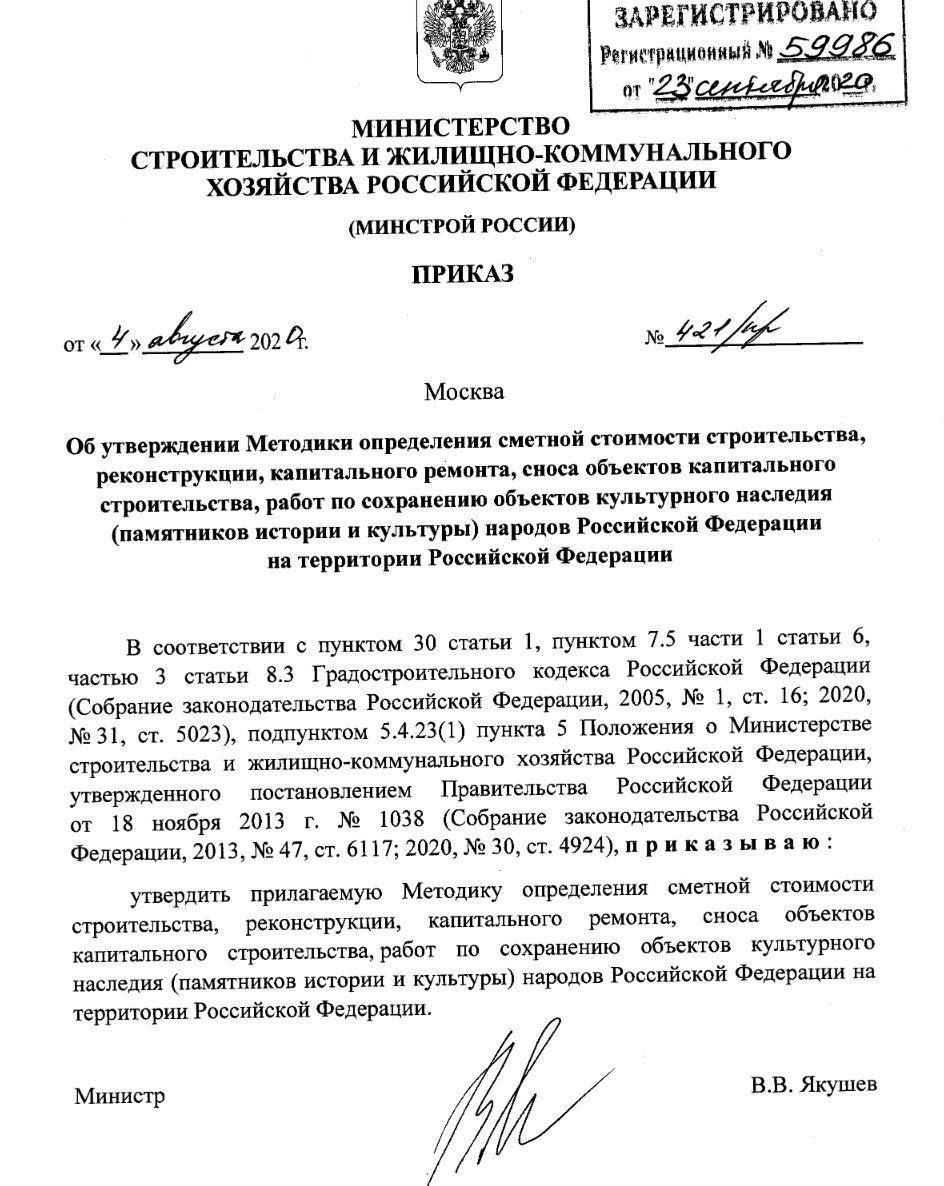
-------------->
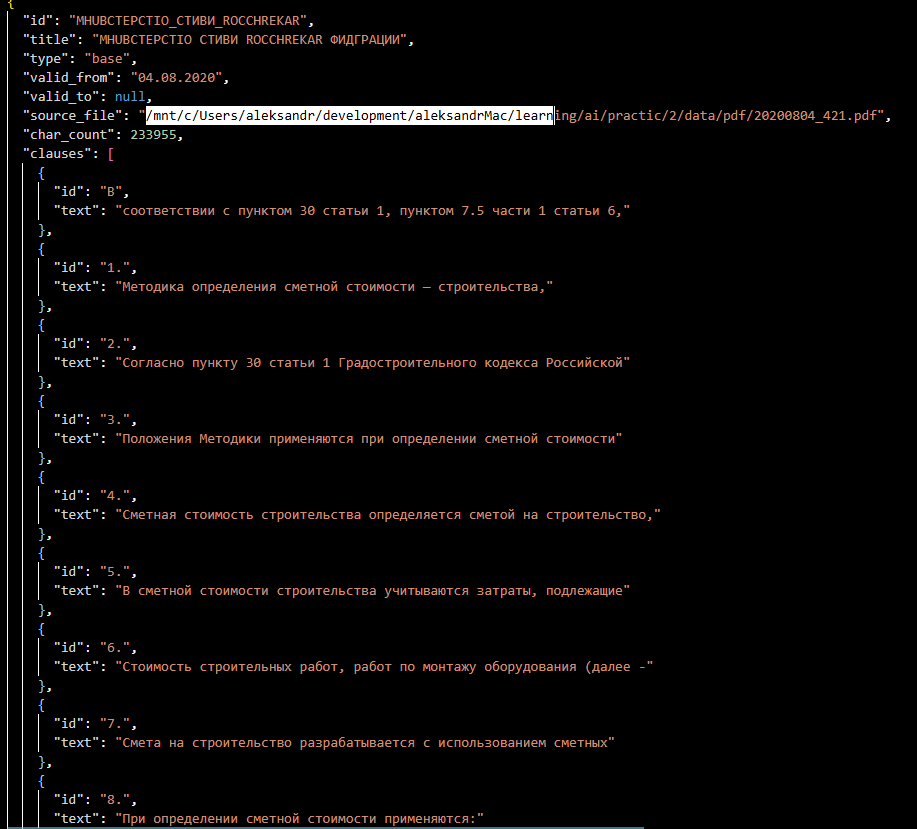